## 1. Environment Setup and Directory Initialization
Before starting the analysis, we define the base project path and establish a dedicated directory for saving generated figures and statistical results. This ensures that all outputs are organized and that the script remains compatible across different local environments by using absolute paths.

Objective: Set up a consistent file structure for the project.

Key Action: Create /figure outputs and /statistical outputs directory if it does not already exist.

In [31]:
import os

# Retrieve the absolute path of the current working directory
# In a Jupyter environment, this points to the folder containing the .ipynb file
base_path = os.getcwd()

# Define and create a 'figures' directory to store analysis plots
# 'exist_ok=True' ensures no error is thrown if the directory already exists
figures_path = os.path.join(base_path, "figure outputs")
os.makedirs(figures_path, exist_ok=True)

statistic_path = os.path.join(base_path,"statistical_outputs")
os.makedirs(statistic_path, exist_ok=True)

print(f"Current project base path: {base_path}")
print(f"Figures directory initialized at: {figures_path}")
print(f"Results directory initialized at: {statistic_path}")

Current project base path: /Users/qgroup/Desktop/final_draft
Figures directory initialized at: /Users/qgroup/Desktop/final_draft/figure outputs
Results directory initialized at: /Users/qgroup/Desktop/final_draft/statistical_outputs


## 2. Story-level Correlation Analysis of Narrative Signals

This section implements a statistical pipeline to measure the relationships between three narrative dimensions: **Surprisal, Coherence, and Semantic Shift**. Following the methodology of Sap et al. (2022), we calculate pairwise Pearson correlations for each story to assess linear dependence and signal redundancy.

### Analysis Workflow:
1. **Data Parsing:** Convert string-formatted sequences (from CSV) into numerical arrays.
2. **Length Alignment:** Synchronize the lengths of the three signal sequences.
3. **Filtering:** Exclude stories with fewer than three sentences to maintain statistical reliability.
4. **Correlation Calculation:** - Compute Pearson's $r$ for Surprisal-Coherence, Surprisal-Semantic, and Coherence-Semantic.
    - Handle edge cases where standard deviation is zero to prevent calculation errors.
5. **Distribution Summary:** The results allow for examining corpus-wide distributions (mean, SD, quartiles) of these narrative interactions.

In [32]:
import pandas as pd
import numpy as np
import ast
from scipy.stats import pearsonr
import os

def safe_to_list(x):
    """
    Converts string representations of lists into actual Python list objects.
    Returns an empty list if parsing fails or input is invalid.
    """
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return []
    return []

def main():
    # 1. Path Configuration and Data Loading
    base_path = "."
    input_file = f"{base_path}/flash_fiction_with_surprisal_coherence_semantic.csv"
    output_file = f"{base_path}/statistical_outputs/flash_fiction_with_correlations.csv"

    if not os.path.exists(input_file):
        print(f"Error: File not found: {input_file}")
        return

    df = pd.read_csv(input_file)

    # 2. Automated Detection of Narrative Signal Columns
    # Identifies columns related to surprisal, coherence, and semantic shift 
    # based on naming patterns.
    col_map = {}
    for col in df.columns:
        if "surprisal" in col and ("vector" in col or "list" in col):
            col_map["surprisal"] = col
        if "coherence" in col and ("vector" in col or "list" in col):
            col_map["coherence"] = col
        if ("semantic_shift" in col or "topic_shift" in col) and ("vector" in col or "list" in col):
            col_map["semantic"] = col

    # 3. Pairwise Correlation Calculation
    corr_sc, corr_sm, corr_cm = [], [], []

    for _, row in df.iterrows():
        # Parse list-like strings into numpy arrays
        s = np.array(safe_to_list(row[col_map["surprisal"]]), dtype=float)
        c = np.array(safe_to_list(row[col_map["coherence"]]), dtype=float)
        m = np.array(safe_to_list(row[col_map["semantic"]]), dtype=float)
        
        # Align lengths based on the shortest signal sequence
        min_len = min(len(s), len(c), len(m))
        
        # Exclude stories with fewer than 3 sentences for statistical significance
        if min_len < 3:
            corr_sc.append(np.nan); corr_sm.append(np.nan); corr_cm.append(np.nan)
            continue
            
        s, c, m = s[:min_len], c[:min_len], m[:min_len]
        
        # Internal helper to handle Pearson correlation with zero-variance edge cases
        def get_r(a, b):
            if np.std(a) == 0 or np.std(b) == 0:
                return 0.0
            return pearsonr(a, b)[0]

        # Calculate correlations for each pair: Surp-Coh, Surp-Sem, Coh-Sem
        corr_sc.append(get_r(s, c))
        corr_sm.append(get_r(s, m))
        corr_cm.append(get_r(c, m))

    # 4. Data Integration and Output
    # Store the resulting coefficients back into the dataframe
    df["corr_surp_coh"] = corr_sc
    df["corr_surp_sem"] = corr_sm
    df["corr_coh_sem"] = corr_cm

    # Save the processed dataset with UTF-8-BOM encoding for compatibility
    df.to_csv(output_file, index=False, encoding="utf-8-sig")
    print(f"Calculation complete. Correlation coefficients saved to: {output_file}")

if __name__ == "__main__":
    main()

Calculation complete. Correlation coefficients saved to: ./statistical_outputs/flash_fiction_with_correlations.csv


## 3. Signal Preprocessing: Normalization, Smoothing, and Burn-in Diagnostic

To facilitate comparison across stories of varying lengths, we transform raw narrative signals into a standardized format. This process involves resampling, smoothing, and identifying initial "burn-in" artifacts to ensure the stability of subsequent structural analysis.

### Key Methodologies:
1. **Length Normalization (Resampling):** Each signal is resampled onto a fixed grid of $L=50$ equidistant positions. This meso-scale representation ($L=50$) preserves structural shape while mitigating high-frequency noise.
2. **Gaussian Smoothing:** A 1D Gaussian filter ($\sigma=2$) is applied to emphasize broad narrative tendencies and further attenuate sentence-level volatility.
3. **Statistical Feature Extraction:** We compute story-level descriptors (mean, standard deviation, peak position, and regional means) to capture the overall profile of each signal.
4. **Z-score Normalization:** Signals are standardized per-story to express values relative to the story-specific mean and variance.
5. **Burn-in Diagnostic:** We analyze the global variance of surprisal across the 50 bins to detect the "elbow" point. This allows us to separate initial processing artifacts (unconditioned model state) from the stable narrative regime.

In [33]:
import pandas as pd
import numpy as np
import ast
import os
from scipy.ndimage import gaussian_filter1d

# ==========================================
# 1. Configuration: Paths and Constants
# ==========================================
base_path = "." 
input_file = f"{base_path}/flash_fiction_with_surprisal_coherence_semantic.csv"
output_curves_file = f"{base_path}/statistical_outputs/flash_fiction_with_all_curves_50.csv"
output_feat_file = f"{base_path}/statistical_outputs/flash_fiction_with_all_features_50.csv"

# Fixed grid length for normalization
L = 50 

# ==========================================
# 2. Utility Functions
# ==========================================
def safe_to_list(x):
    """Parses various input types into a Python list of floats."""
    if isinstance(x, (list, tuple)):
        return list(x)
    if not isinstance(x, str) or not x.strip():
        return []
    try:
        v = ast.literal_eval(x)
        if isinstance(v, (list, tuple)):
            return list(v)
        return []
    except Exception:
        return []

def resample_curve(values, L=50):
    """Resamples a sequence to a fixed length L using linear interpolation."""
    values = safe_to_list(values)
    if not values:
        return [np.nan] * L
    arr = np.array(values, dtype=float)
    T = len(arr)
    if T <= 1:
        return [float(arr[0]) if T == 1 else np.nan] * L
    
    x_orig = np.linspace(0.0, 1.0, T)
    x_new = np.linspace(0.0, 1.0, L)
    interpolated = np.interp(x_new, x_orig, arr)
    return [round(x, 4) for x in interpolated.tolist()]

def smooth_curve(values, sigma=2):
    """Applies 1D Gaussian smoothing to the input signal."""
    arr = np.array(values, dtype=float)
    if len(arr) == 0 or np.all(np.isnan(arr)):
        return arr.tolist()
    smoothed = gaussian_filter1d(arr, sigma=sigma)
    return [round(x, 4) for x in smoothed.tolist()]

def curve_features(values):
    """Extracts statistical and positional descriptors from the narrative signal."""
    values = safe_to_list(values)
    if not values:
        return {
            "len_sents": 0, "mean": np.nan, "std": np.nan, "max_val": np.nan,
            "max_pos_rel": np.nan, "mean_begin": np.nan, "mean_middle": np.nan, "mean_end": np.nan,
        }
    arr = np.array(values, dtype=float)
    T = len(arr)
    mean = float(arr.mean()) if T > 0 else np.nan
    std = float(arr.std()) if T > 0 else np.nan
    max_val = float(arr.max()) if T > 0 else np.nan
    argmax = int(arr.argmax()) if T > 0 else 0
    max_pos_rel = argmax / (T - 1) if T > 1 else 0
    
    # Divide the narrative into three equal segments: Beginning, Middle, End
    b_end = max(1, T // 3)
    m_end = max(b_end + 1, 2 * T // 3)
    begin = float(arr[:b_end].mean()) if b_end > 0 else np.nan
    middle = float(arr[b_end:m_end].mean()) if m_end > b_end else np.nan
    end = float(arr[m_end:].mean()) if T > m_end else np.nan
    
    return {
        "len_sents": T, "mean": mean, "std": std, "max_val": max_val,
        "max_pos_rel": max_pos_rel, "mean_begin": begin, "mean_middle": middle, "mean_end": end,
    }

# ==========================================
# 3. Execution: Data Processing
# ==========================================
if not os.path.exists(input_file):
    print(f"Error: File not found: {input_file}")
else:
    df = pd.read_csv(input_file)
    print(f"Total stories loaded: {len(df)}")

    # 4. Vector Cleaning
    # Synchronize column naming for surprisal, coherence, and semantic shift
    df["surprisal_list"] = df.get("surprisal_vector", df.get("surprisal_list", "[]")).apply(safe_to_list)
    df["coherence_list"] = df.get("coherence_vector", df.get("coherence_list", "[]")).apply(safe_to_list)
    df["semantic_shift_list"] = df.get("semantic_shift_vector", df.get("semantic_shift_list", "[]")).apply(safe_to_list)

    # 5. Curve Generation (Normalization & Smoothing)
    print("Generating 50-bin curves...")
    for col in ["surprisal", "coherence", "semantic_shift"]:
        raw_list_col = f"{col}_list"
        df[f"{col}_curve_50_raw"] = df[raw_list_col].apply(lambda v: resample_curve(v, L=L))
        df[f"{col}_curve_50_smooth"] = df[f"{col}_curve_50_raw"].apply(lambda v: smooth_curve(v, sigma=2))

    df.to_csv(output_curves_file, index=False, encoding="utf-8-sig")

    # 6. Statistical Feature Extraction
    print("Extracting story-level statistical features...")
    surp_feat = df["surprisal_list"].apply(curve_features).apply(pd.Series).add_prefix("surp_")
    coh_feat = df["coherence_list"].apply(curve_features).apply(pd.Series).add_prefix("coh_")
    sem_feat = df["semantic_shift_list"].apply(curve_features).apply(pd.Series).add_prefix("sem_")

    df_feat = pd.concat([df, surp_feat, coh_feat, sem_feat], axis=1)
    df_feat.to_csv(output_feat_file, index=False, encoding="utf-8-sig")
    print("Processing complete. Files saved.")

Total stories loaded: 2636
Generating 50-bin curves...
Extracting story-level statistical features...
Processing complete. Files saved.



Bin Index  | Variance   | % Drop
-----------------------------------
Bin 0         | 1.5555     | -
Bin 1         | 1.1644     | 25.1%
Bin 2         | 0.8186     | 29.7%
Bin 3         | 0.7137     | 12.8%
Bin 4         | 0.7313     | -2.5%
Bin 5         | 0.7581     | -3.7%
Bin 6         | 0.7663     | -1.1%
Bin 7         | 0.7647     | 0.2%
Bin 8         | 0.7694     | -0.6%
Bin 9         | 0.7838     | -1.9%


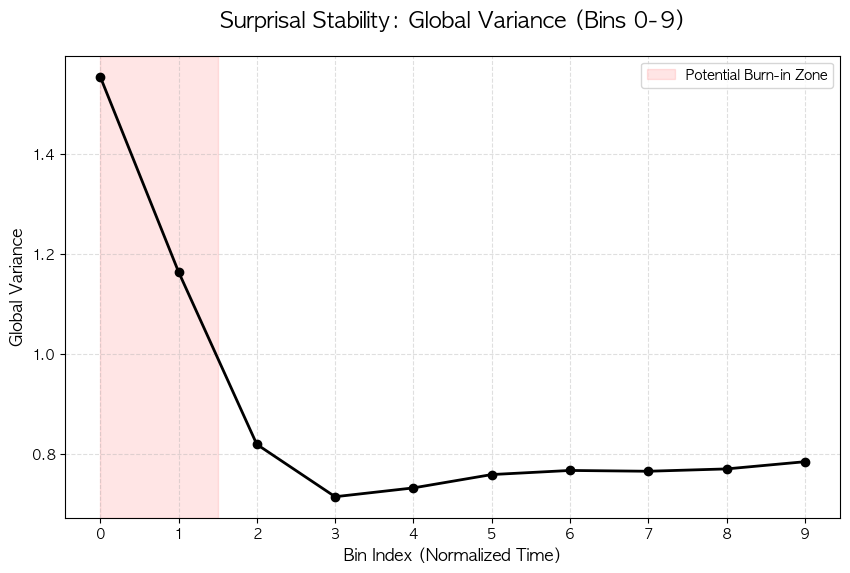

In [34]:
import pandas as pd
import numpy as np
import ast
import os
import matplotlib.pyplot as plt

def safe_to_list(x):
    """Safely converts string representations of lists back to Python objects."""
    if isinstance(x, (list, tuple)): return list(x)
    try: return list(ast.literal_eval(x))
    except: return []

def main():
    base_path = "."
    input_file = f"{base_path}/statistical_outputs/flash_fiction_with_all_curves_50.csv"
    
    if not os.path.exists(input_file):
        print("Error: Please run the preprocessing script (Code Cell 1) first.")
        return

    df = pd.read_csv(input_file)
    
    # 1. Z-score Normalization across Preprocessed Curves
    # Use smoothed 50-bin surprisal curves for stability analysis
    curves = df["surprisal_curve_50_smooth"].apply(safe_to_list)
    
    processed_curves = []
    for c in curves:
        if len(c) == 50:
            arr = np.array(c)
            # Apply per-story Z-score normalization to focus on dispersion
            std_val = np.std(arr)
            if std_val > 0:
                processed_curves.append((arr - np.mean(arr)) / std_val)

    # Stack curves to compute global variance at each of the 50 positions
    X = np.vstack(processed_curves)
    global_vars = np.var(X, axis=0)

    # 2. Burn-in Zone Analysis (Inspection of the first 10 bins)
    limit = 10 
    indices = np.arange(limit)
    vars_to_show = global_vars[:limit]

    print(f"\n{'Bin Index':<10} | {'Variance':<10} | {'% Drop'}")
    print("-" * 35)
    for i, v in enumerate(vars_to_show):
        drop = f"{(vars_to_show[i-1]-v)/vars_to_show[i-1]*100:.1f}%" if i > 0 else "-"
        print(f"Bin {i:<9} | {v:<10.4f} | {drop}")

    # 3. Visualization of Stability Diagnostic
    plt.figure(figsize=(10, 6))
    # Highlight potential burn-in zone based on variance elbow
    plt.axvspan(0, 1.5, color='red', alpha=0.1, label='Potential Burn-in Zone')
    plt.plot(indices, vars_to_show, marker='o', color='black', linewidth=2)
    
    plt.title("Surprisal Stability: Global Variance (Bins 0-9)", fontsize=16, pad=20)
    plt.xlabel("Bin Index (Normalized Time)", fontsize=12)
    plt.ylabel("Global Variance", fontsize=12)
    plt.xticks(indices)
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.legend()
    
    # Export the diagnostic figure for research documentation
    os.makedirs(f"{base_path}/figure outputs", exist_ok=True)
    plt.savefig(f"{base_path}/figure outputs/burn_in_diagnostic_0_9.png", dpi=300)
    plt.show()

if __name__ == "__main__":
    main()

## 4. Surprisal-based Trajectory Clustering and Validation

This section identifies archetypal narrative structures by clustering surprisal trajectories. To eliminate initialization artifacts and focus on meaningful narrative development, the analysis is restricted to the **stable narrative region (Bins 2–49)**. The workflow ensures that the identified archetypes are not only mathematically distinct but also statistically robust.

### Analysis Workflow:

1.  **Data Preprocessing and Normalization:** Extract the stable narrative region and apply **$z$-score normalization** to each trajectory. This shifts the focus from absolute surprisal levels to the relative morphological changes (arcs) within each story.
2.  **Optimal K Selection:** Determine the natural number of clusters ($k$) by evaluating **Inertia (SSE)** and **Silhouette Scores**. The 'elbow' point is automatically detected using the **KneeLocator** to ensure objective cluster selection.
3.  **Clustering and Stability Validation:** Partition the trajectories into $k$ archetypes using **K-means clustering**. Robustness is confirmed by calculating the **Adjusted Rand Index (ARI)** across multiple random seeds to ensure label stability.
4.  **Structural Feature Extraction:** Compute four key shape-based descriptors for each story to enable statistical comparison:
    * **Peak Position:** The relative narrative timing of the maximum surprisal.
    * **Maximum Intensity:** The height of the primary surprisal shock ($z$-score).
    * **Peak Frequency:** The count of local maxima exceeding a threshold ($z > 1.0$).
    * **Volatility:** The standard deviation of surprisal within the stable region.
5.  **Assumption-Driven Statistical Testing:** Execute a rigorous validation pipeline:
    * **Diagnostic Tests:** Assess normality (**Shapiro-Wilk**) and homogeneity of variance (**Levene’s test**).
    * **Omnibus Tests:** Perform **ANOVA** if assumptions are met, or the non-parametric **Kruskal-Wallis test** otherwise, to verify significant differences between archetypes.
    * **Post-hoc Analysis:** Apply **Tukey HSD** or **Dunn’s test (with Bonferroni correction)** to identify specific pairwise differences between archetypes.
6.  **Archetype Profiling and Climax Modeling:** Characterize the spatial concentration of narrative shocks using **Kernel Density Estimation (KDE)**. This includes identifying the **temporal mode** (the most frequent climax point) and calculating the **multi-peak ratio** for each archetype.

Step 1: Loading data and performing Z-score normalization...
Step 2: Searching for optimal number of clusters (K)...
=> Optimal K detected: 5


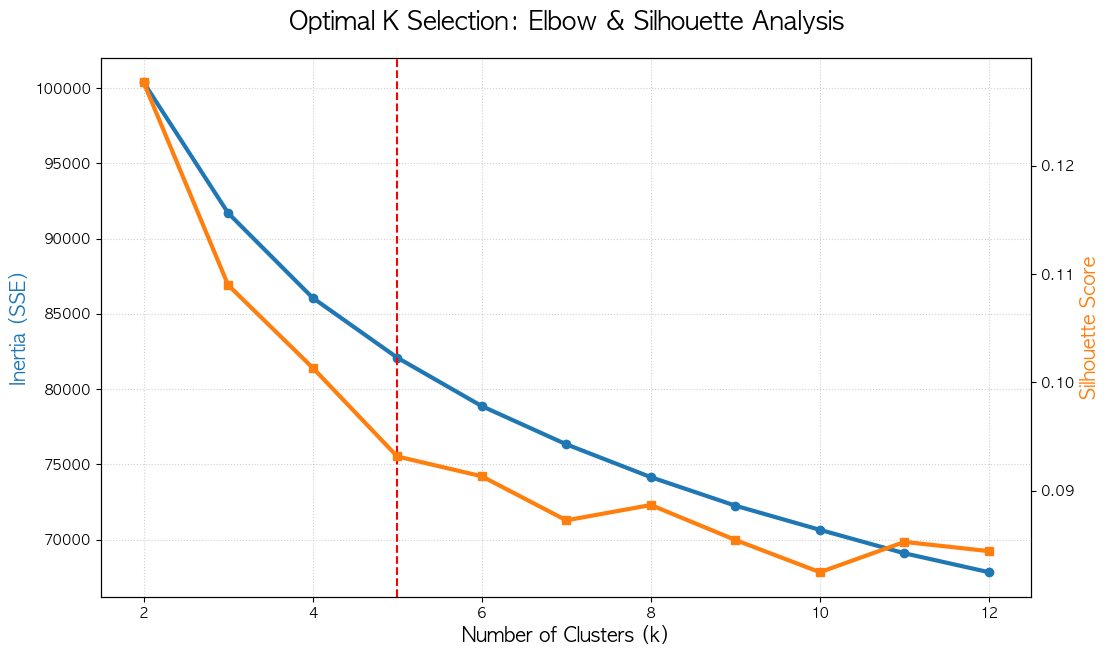

Step 3: Performing K-means clustering (K=5) and ARI validation...
★ Mean ARI: 0.8164 (High stability confirmed)
Step 4: Computing structural descriptors for statistical validation...

★ Data saved: flash_fiction_clustered_surprisal_stable.csv
Step 5: Conducting diagnostic tests, Omnibus tests, and Post-hoc analysis...

=== Statistical Validation Summary ===
           Variable            Test  Shapiro_min_p       Levene_p  F-stat  \
0    surp_peak_pos  Kruskal-Wallis   4.840288e-36  1.083950e-167     NaN   
1     surp_max_val  Kruskal-Wallis   5.593886e-15   5.948052e-15     NaN   
2          n_peaks  Kruskal-Wallis   7.774042e-27   3.575918e-01     NaN   
3  surp_std_stable  Kruskal-Wallis   1.229264e-35   6.505101e-01     NaN   

           p_val      H-stat  
0  7.216530e-102  476.730592  
1   2.081059e-33  159.284913  
2   4.623930e-22  106.233542  
3   6.120818e-01    2.683632  

=== Detailed Post-hoc Analysis (Significant only) ===

[Variable: surp_peak_pos]
              0      

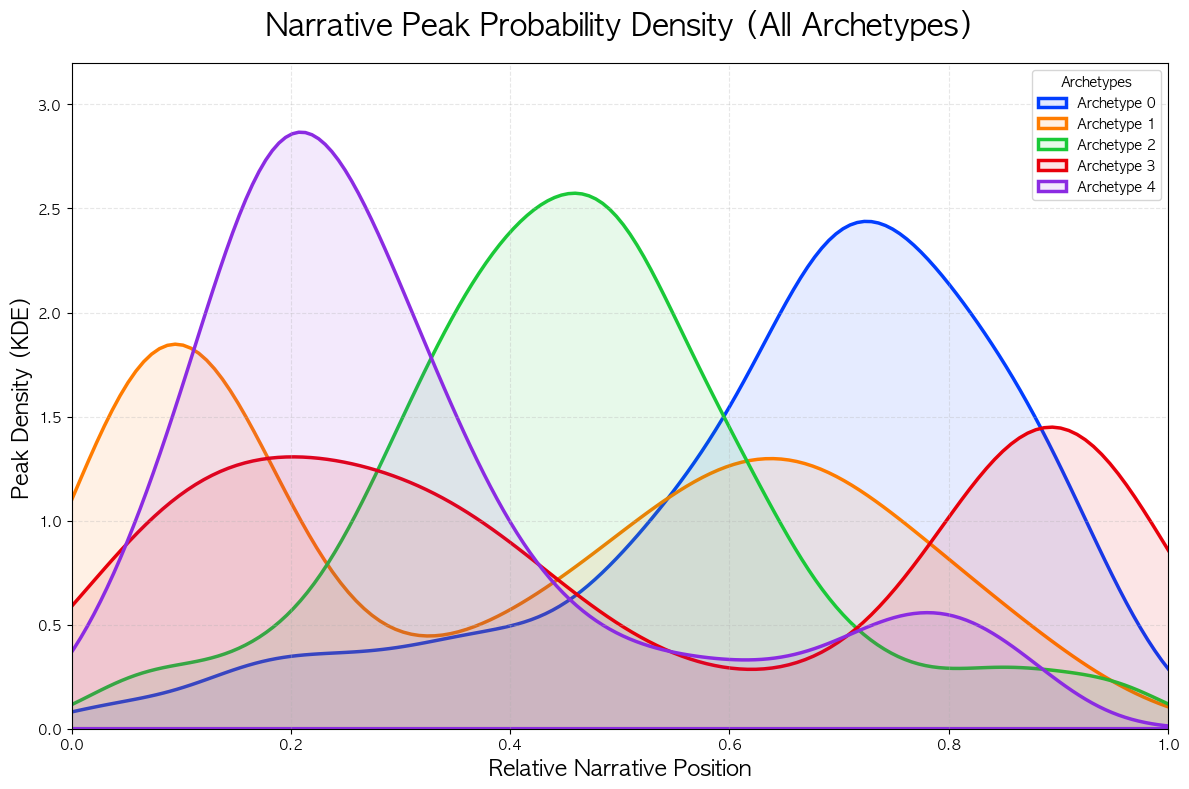

Visualization complete. All figures share the same scale (Y: 0-3.2).


In [35]:
import os
import pandas as pd
import numpy as np
import ast
import platform
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from scipy.stats import zscore, f_oneway, kruskal, gaussian_kde
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
import seaborn as sns
from kneed import KneeLocator

from scipy.stats import shapiro, levene  # 위 import에 추가

import scikit_posthocs as sp
from scipy.stats import shapiro, levene, kruskal, f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd



# ==========================================
# 0. Environment Setup: Fonts and Paths
# ==========================================
def set_korean_font():
    """Sets appropriate Korean fonts for plotting based on the OS."""
    system = platform.system()
    if system == "Darwin": plt.rc('font', family='AppleGothic')
    elif system == "Windows": plt.rc('font', family='Malgun Gothic')
    plt.rcParams['axes.unicode_minus'] = False

set_korean_font()
base_path = "." 
os.makedirs(f"{base_path}/figure outputs", exist_ok=True)

# ==========================================
# 1. Data Loading and Stable Region Extraction
# ==========================================
print("Step 1: Loading data and performing Z-score normalization...")
df = pd.read_csv(f"{base_path}/statistical_outputs/flash_fiction_with_all_curves_50.csv")

def safe_vec(x):
    """Safely converts string representations to list objects."""
    try: return list(ast.literal_eval(x))
    except: return []

df["surp_curve"] = df["surprisal_curve_50_smooth"].apply(safe_vec)
# Filter stories with valid lengths and reset index
df = df[df["surp_curve"].map(len) == 50].reset_index(drop=True)

# Extract stable region (Bins 2-49) and apply Z-score normalization
# This removes 'burn-in' noise and focuses on the narrative trajectory shape
X_raw_stable = np.vstack(df["surp_curve"].values)[:, 2:] 
X_scaled = np.nan_to_num(zscore(X_raw_stable, axis=1))

# ==========================================
# 2. Optimal K Exploration (Elbow & Silhouette)
# ==========================================
print("Step 2: Searching for optimal number of clusters (K)...")
ks = range(2, 13)
inertias, silhouettes = [], []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=20).fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

# Automatically detect the 'elbow' point
best_k = KneeLocator(ks, inertias, curve='convex', direction='decreasing').knee or 5
print(f"=> Optimal K detected: {best_k}")

# Visualization: Elbow and Silhouette Analysis
fig, ax1 = plt.subplots(figsize=(12, 7))
ax1.set_xlabel('Number of Clusters (k)', fontsize=14)
ax1.set_ylabel('Inertia (SSE)', color='tab:blue', fontsize=14)
ax1.plot(ks, inertias, marker='o', color='tab:blue', linewidth=3, label='Inertia')
ax1.axvline(x=best_k, color='red', linestyle='--', label=f'Optimal K={best_k}')

ax2 = ax1.twinx()  
ax2.set_ylabel('Silhouette Score', color='tab:orange', fontsize=14)
ax2.plot(ks, silhouettes, marker='s', color='tab:orange', linewidth=3, label='Silhouette')

plt.title('Optimal K Selection: Elbow & Silhouette Analysis', fontsize=18, pad=20)
ax1.grid(True, linestyle=':', alpha=0.6)
plt.savefig(f"{base_path}/figure outputs/optimal_k_validation.png", dpi=300)
plt.show()

# ==========================================
# 3. Clustering and Robustness Check (ARI)
# ==========================================
print(f"Step 3: Performing K-means clustering (K={best_k}) and ARI validation...")
base_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
df["cluster_surp"] = base_kmeans.fit_predict(X_scaled)

# Check label stability across different random seeds using Adjusted Rand Index (ARI)
ari_list = [adjusted_rand_score(df["cluster_surp"], 
            KMeans(n_clusters=best_k, random_state=s, n_init=20).fit_predict(X_scaled)) 
            for s in range(10, 20)]

print(f"★ Mean ARI: {np.mean(ari_list):.4f} (High stability confirmed)")

# ==========================================
# 4. Feature Extraction: Shape Descriptors
# ==========================================
print("Step 4: Computing structural descriptors for statistical validation...")
# Relative position of the primary peak
df["surp_peak_pos"] = (X_scaled.argmax(axis=1)) / (X_scaled.shape[1] - 1)
# Maximum intensity (Z-score)
df["surp_max_val"] = X_scaled.max(axis=1)
# Number of peaks exceeding Z > 1.0
df["n_peaks"] = [len(find_peaks(row, height=1.0)[0]) for row in X_scaled]
# Volatility within the stable region
df["surp_std_stable"] = X_scaled.std(axis=1)

output_filename = "flash_fiction_clustered_surprisal_stable.csv"
df.to_csv(f"{base_path}/statistical_outputs/{output_filename}", index=False, encoding='utf-8-sig')
print(f"\n★ Data saved: {output_filename}")

# ==========================================
# 5. Statistical Significance Testing (Integrated)
# ==========================================
print("Step 5: Conducting diagnostic tests, Omnibus tests, and Post-hoc analysis...")

descriptors = ["surp_peak_pos", "surp_max_val", "n_peaks", "surp_std_stable"]
test_results = []
posthoc_reports = {} # dictionary to store post-hoc test results

alpha = 0.05

for var in descriptors:
    # Create data groups for each cluster
    groups = [df[df["cluster_surp"] == k][var].dropna().values for k in range(best_k)]
    
    # 5-1. Normality test (Shapiro-Wilk)
    shapiro_ps = []
    for g in groups:
        if len(g) >= 3:
            _, p_sw = shapiro(g)
            shapiro_ps.append(p_sw)
    
    # All groups must satisfy normality for ANOVA
    normal = len(shapiro_ps) > 0 and all(p > alpha for p in shapiro_ps)
    
    # 5-2. Homogeneity of variance test (Levene)
    p_lev = np.nan
    if all(len(g) >= 2 for g in groups):
        _, p_lev = levene(*groups)
        equal_var = p_lev > alpha
    else:
        equal_var = False
    
    # 5-3. Choose test and post-hoc procedure based on assumptions
    if normal and equal_var:
        # ANOVA
        test_used = "ANOVA"
        f_stat, p_val = f_oneway(*groups)
        
        # Post-hoc: Tukey HSD
        if p_val < alpha:
            posthoc = pairwise_tukeyhsd(df[var], df['cluster_surp'], alpha=alpha)
            posthoc_reports[var] = posthoc
        
        res = {"F-stat": f_stat, "p_val": p_val, "H-stat": np.nan}
    else:
        # Kruskal-Wallis
        test_used = "Kruskal-Wallis"
        h_stat, p_val = kruskal(*groups)
        
        # Post-hoc: Dunn's test (Bonferroni correction)
        if p_val < alpha:
            # using scikit-posthocs
            posthoc = sp.posthoc_dunn(df, val_col=var, group_col='cluster_surp', p_adjust='bonferroni')
            posthoc_reports[var] = posthoc
            
        res = {"F-stat": np.nan, "p_val": p_val, "H-stat": h_stat}
    
    # Save data for summary table
    test_results.append({
        "Variable": var,
        "Test": test_used,
        "Shapiro_min_p": np.min(shapiro_ps) if shapiro_ps else np.nan,
        "Levene_p": p_lev,
        **res
    })

# Print overall summary table
results_table = pd.DataFrame(test_results)
print("\n=== Statistical Validation Summary ===\n", results_table)

# Print detailed post-hoc results
print("\n=== Detailed Post-hoc Analysis (Significant only) ===")
for var, report in posthoc_reports.items():
    print(f"\n[Variable: {var}]")
    print(report)

# ============================================================
# 6. Archetype Profiling: Final Statistical Table Generation
# ============================================================
print("Step 6: Generating integrated statistical profile for narrative archetypes...")

# Aggregate summary statistics (n, Mean, SD, and Multi-peak Ratio)
summary_stats = df.groupby("cluster_surp")["n_peaks"].agg(
    n="count",
    Mean="mean",
    SD="std",
    Multi_pct=lambda x: (x >= 2).sum() / len(x) * 100
).round(3)

# Calculate the probability distribution of peak counts (0 to 4 peaks) per archetype
peak_distribution = pd.crosstab(df["cluster_surp"], df["n_peaks"], normalize='index') * 100
peak_distribution = peak_distribution.round(2)
peak_distribution.columns = [f"Peak_{int(c)}" for c in peak_distribution.columns]

# Concatenate intensity measures and distribution values into a single master table
final_table = pd.concat([summary_stats, peak_distribution], axis=1)
final_table.index.name = "Archetype"

print("\n=== Table 4: Statistical profile of narrative activity per archetype ===")
print(final_table)
final_table.to_csv(f"{base_path}/statistical_outputs/archetype_statistical_profile.csv", encoding='utf-8-sig')

# ==========================================
# 7. Visualization: Peak Density Estimation (KDE)
# ==========================================
print("Step 7: Generating Kernel Density Estimation plots with standardized axes...")

# Collect all peak positions for KDE
peak_list = []
for i in range(len(X_scaled)):
    peaks, _ = find_peaks(X_scaled[i], height=1.0)
    for p in peaks:
        peak_list.append({
            "cluster": df.loc[i, "cluster_surp"], 
            "peak_pos": p / (X_scaled.shape[1] - 1)
        })

df_peaks = pd.DataFrame(peak_list)
colors = sns.color_palette("bright", best_k)

# [A] Global Comparison KDE (All Archetypes)
plt.figure(figsize=(12, 8))
for k in range(best_k):
    subset_peaks = df_peaks[df_peaks["cluster"] == k]
    if not subset_peaks.empty:
        sns.kdeplot(data=subset_peaks, x="peak_pos", color=colors[k], 
                    fill=True, alpha=0.1, linewidth=2.5, label=f"Archetype {k}")

plt.title("Narrative Peak Probability Density (All Archetypes)", fontsize=22, pad=20)
plt.xlabel("Relative Narrative Position", fontsize=16)
plt.ylabel("Peak Density (KDE)", fontsize=16)

# Standardized Axis Settings
plt.ylim(0, 3.2)
plt.yticks([0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0])
plt.xlim(0, 1)

plt.legend(title="Archetypes", loc='upper right')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{base_path}/figure outputs/all_clusters_comparison_kde_multi.png", dpi=300)
plt.show()

# [B] Individual Archetype Profiles with Mode Detection
for k in range(best_k):
    subset_peaks = df_peaks[df_peaks["cluster"] == k]
    n_stories = len(df[df["cluster_surp"] == k])
    
    if len(subset_peaks) > 1:
        plt.figure(figsize=(8, 6))
        sns.kdeplot(data=subset_peaks, x="peak_pos", color=colors[k], fill=True, alpha=0.4, linewidth=3)
        
        # Numeric mode detection
        x_range = np.linspace(0, 1, 1000)
        kde_function = gaussian_kde(subset_peaks["peak_pos"])
        y_values = kde_function(x_range)
        mode_x = x_range[np.argmax(y_values)]
        
        # Add mode indicator line
        plt.axvline(x=mode_x, color=colors[k], linestyle='--', alpha=0.8, label=f'Mode: {mode_x:.2f}')
        
        # Standardized Titles and Labels
        plt.title(f"Archetype {k}: Peak Density Profile\n(Stories: {n_stories})", fontsize=18)
        plt.xlabel("Relative Narrative Position", fontsize=15)
        plt.ylabel("KDE Probability Density", fontsize=15)
        
        # Standardized Axis Settings (Matching Global Plot)
        plt.ylim(0, 3.2)
        plt.yticks([0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0])
        plt.xlim(0, 1)
        
        plt.legend(loc='upper right')
        plt.grid(True, axis='y', linestyle=':', alpha=0.5)
        plt.tight_layout()
        plt.savefig(f"{base_path}/figure outputs/cluster_{k}_kde_detail_multi.png", dpi=300)
        plt.close()

print("Visualization complete. All figures share the same scale (Y: 0-3.2).")

## 5. Characterizing Archetypal Narrative Arcs

After validating the clusters, we analyze the narrative patterns of each archetype through a multi-layered approach.

### Analysis Dimensions:
1. **Master Curves:** A representative "master curve" is calculated for each cluster using the bin-wise arithmetic mean of all trajectories.
2. **Prototypical Narratives:** We identify "prototypes"—individual stories whose trajectories are closest to the cluster centroid in terms of Euclidean distance. 
3. **Qualitative Inspection (Copyright Note):** - Due to copyright restrictions, the actual text content (`sentence_list`) and its derived metadata (e.g., `surp_len_sents`) have been excluded from this script.
    - The filtering logic based on sentence count has been disabled, and the prototype selection now relies on the structural integrity of the resampled curves.

[INFO] Loading clustered narrative data: ./statistical_outputs/flash_fiction_clustered_surprisal_stable.csv

Archetype    | Rank  | Title (EN)               
----------------------------------------------------------------------
Archetype 0  | Rank 1  | Overcoming COVID-44      
Archetype 0  | Rank 2  | Infiltration             
Archetype 0  | Rank 3  | Laughter Injection       


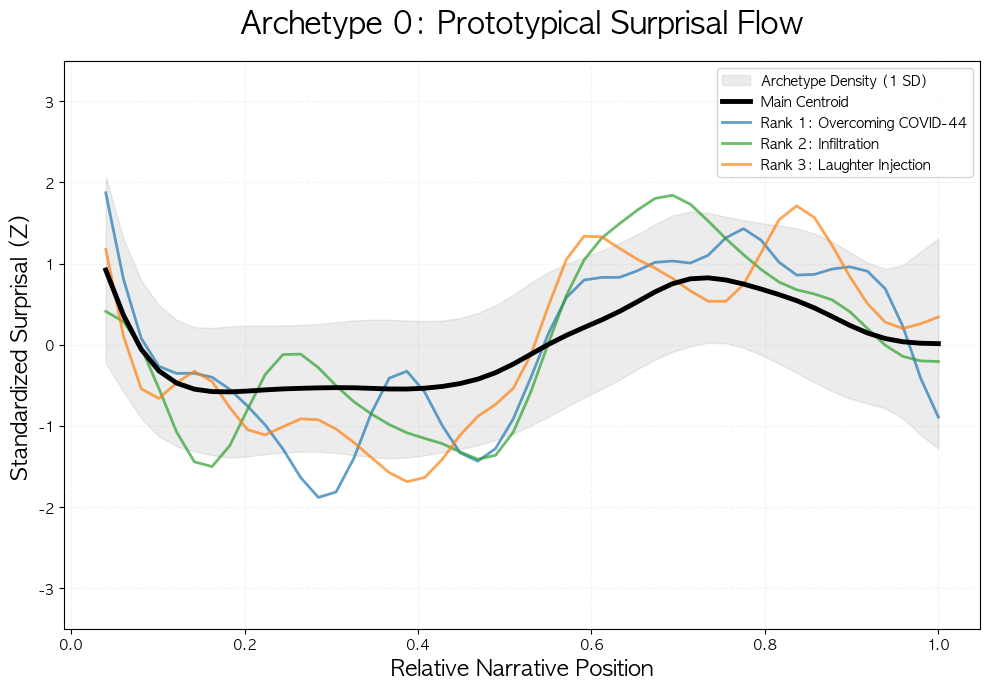

Archetype 1  | Rank 1  | God's Shoes              
Archetype 1  | Rank 2  | Momo-nim                 
Archetype 1  | Rank 3  | A Certain Graduation     


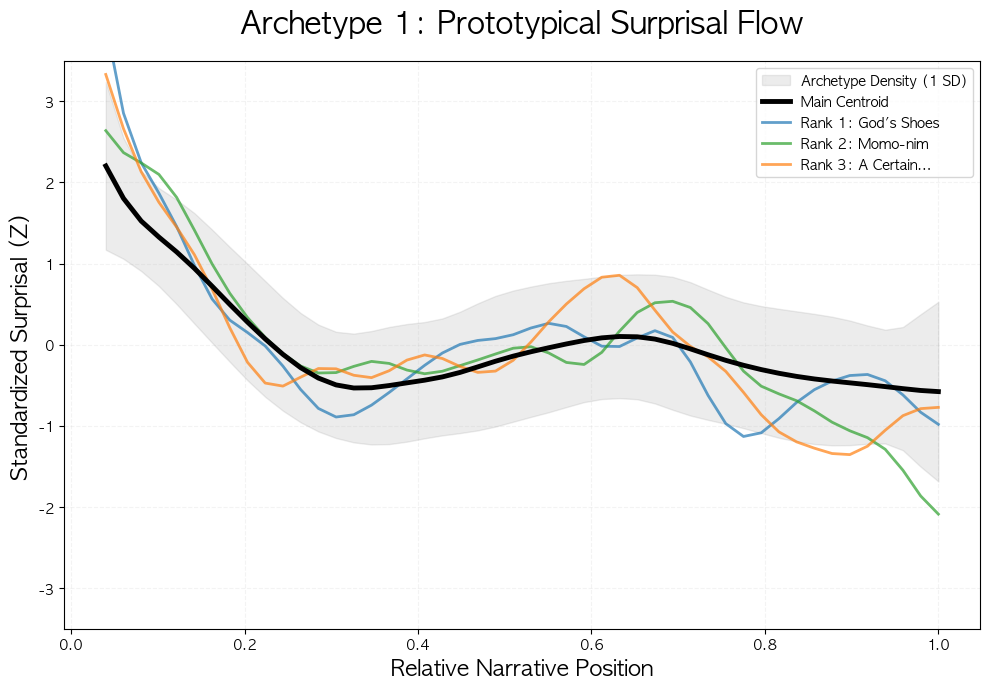

Archetype 2  | Rank 1  | Friday                   
Archetype 2  | Rank 2  | Run, Son                 
Archetype 2  | Rank 3  | Byeokryeon Port...       


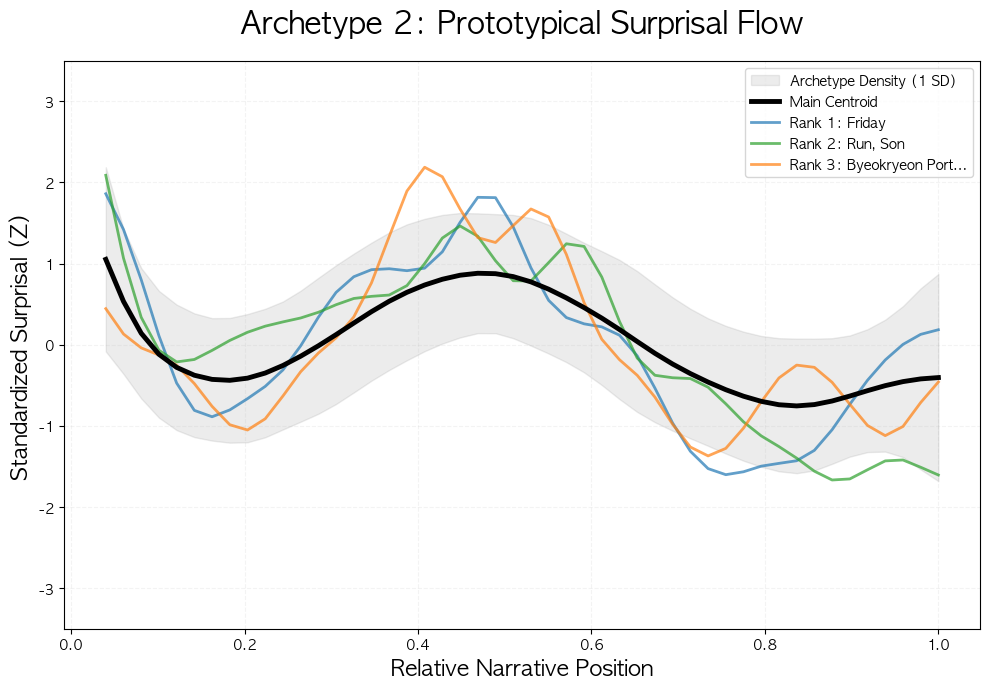

Archetype 3  | Rank 1  | Our Predestined Autumn   
Archetype 3  | Rank 2  | Remote Control           
Archetype 3  | Rank 3  | Short Accompaniment      


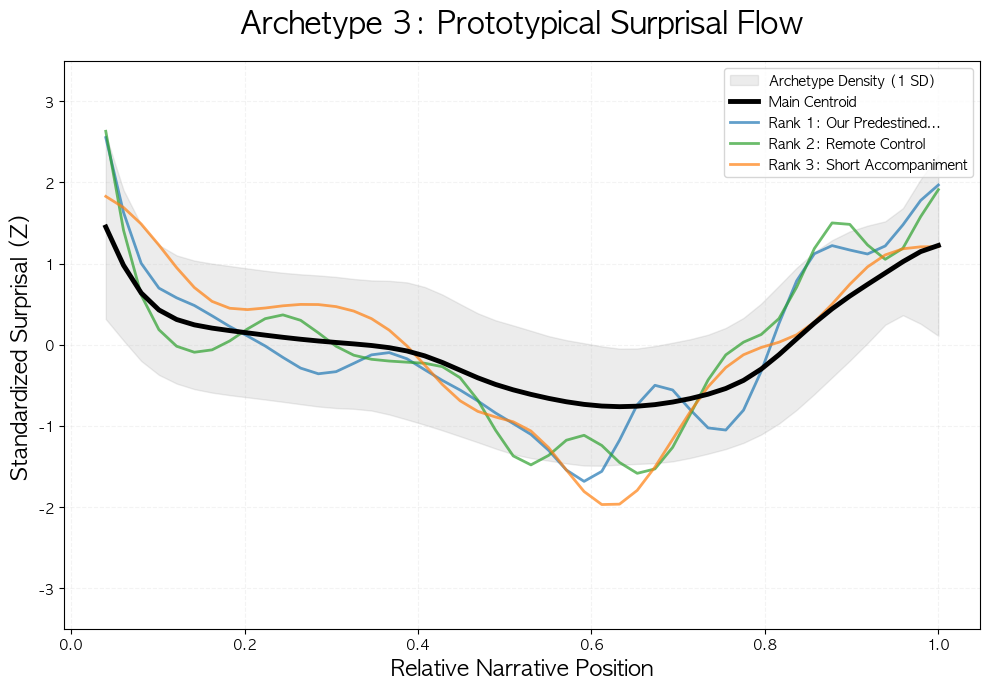

Archetype 4  | Rank 1  | Realization              
Archetype 4  | Rank 2  | Lost Beast               
Archetype 4  | Rank 3  | Because of Sleet         


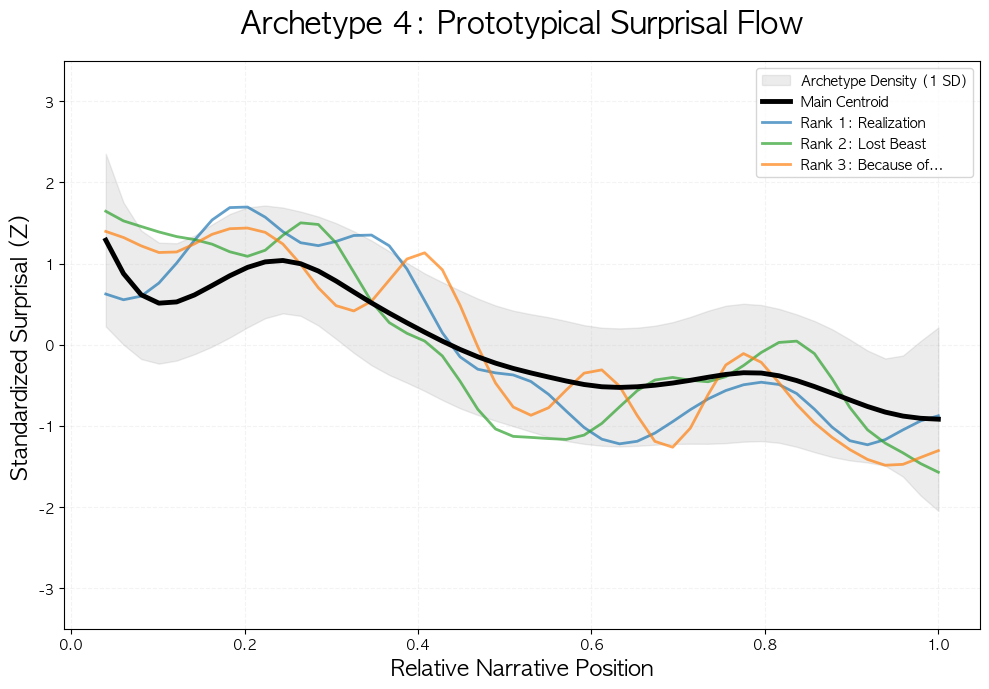


[SUCCESS] Analysis complete. Representative metadata saved to: ./statistical_outputs/surprisal_representative_prototypes.csv


In [36]:
import os
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from scipy.spatial.distance import euclidean
import platform

# ==========================================
# 0. Visualization Setup
# ==========================================
def set_korean_font():
    """Sets the font based on OS for Korean text support in plots."""
    system = platform.system()
    if system == "Darwin": plt.rc('font', family='AppleGothic')
    elif system == "Windows": plt.rc('font', family='Malgun Gothic')
    plt.rcParams['axes.unicode_minus'] = False

set_korean_font()

# ==========================================
# 1. Configuration and Translation Mapping
# ==========================================
base_path = "." 
input_clustered_file = f"{base_path}/statistical_outputs/flash_fiction_clustered_surprisal_stable.csv"
output_rep_csv = f"{base_path}/statistical_outputs/surprisal_representative_prototypes.csv"
output_fig_dir = f"{base_path}/figure outputs"

# MIN_SENTENCES = 10 # [DISABLED] Requires sentence_list column
os.makedirs(output_fig_dir, exist_ok=True)

# ISBN to English Title mapping for academic reporting
TRANSLATION_MAP = {
    "9791192333014": "Overcoming COVID-44",
    "9791163472896": "Infiltration",
    "9791197603655": "Laughter Injection",
    "9788954629386": "God's Shoes",
    "9791197103803": "Momo-nim",
    "9788960907706": "A Certain Graduation",
    "9791167374462": "Friday",
    "9788960902572": "Run, Son",
    "9791168611092": "Byeokryeon Port...",
    "9791187433088": "Our Predestined Autumn",
    "9788993632583": "Remote Control",
    "9788969890337": "Short Accompaniment",
    "9791165699208": "Realization",
    "9791197114656": "Lost Beast",
    "9791130810898": "Because of Sleet"
}

def safe_vec(x):
    """Safely handles string representations of lists/arrays."""
    if isinstance(x, list): return x
    try: return list(ast.literal_eval(x))
    except: return []

def get_truncated_title(isbn):
    """Shortens English titles for legend readability."""
    full_title = TRANSLATION_MAP.get(str(isbn), "Unknown Title")
    words = full_title.split()
    return f"{words[0]} {words[1]}..." if len(words) >= 3 else full_title

# ==========================================
# 2. Main Analysis and Prototyping
# ==========================================
def main():
    print(f"[INFO] Loading clustered narrative data: {input_clustered_file}")
    df = pd.read_csv(input_clustered_file)
    
    # Pre-processing: Parsing smoothed curves
    df["vec_s"] = df["surprisal_curve_50_smooth"].apply(safe_vec)
    df = df[df["vec_s"].map(len) == 50].reset_index(drop=True)
    
    # [DISABLED] n_sents calculation (requires raw text column)
    # if 'n_sents' not in df.columns and 'sentence_list' in df.columns:
    #     df['n_sents'] = df['sentence_list'].apply(lambda x: len(safe_vec(x)))
    
    # Extract stable region (Bins 2-49) and apply Z-score normalization
    X_raw_full = np.vstack(df["vec_s"].values)
    X_stable = X_raw_full[:, 2:] 
    X_scaled = np.nan_to_num(zscore(X_stable, axis=1))
    
    all_stds = X_scaled.std(axis=1)
    clusters = sorted(df["cluster_surp"].unique())
    rep_list = []
    x_axis = np.linspace(0.04, 1.0, 48)

    print("\n" + "="*70)
    print(f"{'Archetype':<12} | {'Rank':<5} | {'Title (EN)':<25}")
    print("-" * 70)

    for k in clusters:
        indices_all = df.index[df["cluster_surp"] == k].tolist()
        cluster_vecs = X_scaled[indices_all]
        
        # Calculate cluster centroid (Master Curve)
        centroid = cluster_vecs.mean(axis=0)
        std_band = cluster_vecs.std(axis=0) 
        
        # Filter valid candidates (non-zero variance only)
        # Note: Length-based filter is disabled as n_sents is unavailable
        candidate_indices = df.index[
            (df["cluster_surp"] == k) & 
            (all_stds > 1e-5)
        ].tolist()

        if not candidate_indices: continue

        # Rank by Euclidean distance to the centroid
        cluster_distances = sorted([(euclidean(X_scaled[idx], centroid), idx) for idx in candidate_indices])
        top_10 = cluster_distances[:10]

        # --- Visualization Per Archetype ---
        fig, ax = plt.subplots(figsize=(10, 7))
        ax.fill_between(x_axis, centroid - std_band, centroid + std_band, color='gray', alpha=0.15, label='Archetype Density (1 SD)')
        ax.plot(x_axis, centroid, color='black', linewidth=3.5, label='Main Centroid', zorder=10)
        
        colors = ['#1f77b4', '#2ca02c', '#ff7f0e']
        for i, (dist, idx) in enumerate(top_10[:3]):
            row = df.loc[idx]
            isbn_str = str(row['isbn'])
            display_title = get_truncated_title(isbn_str)
            
            # [DISABLED] Peak sentence mapping logic
            # peak_bin_idx = np.argmax(X_scaled[idx]) 
            # sents = safe_vec(row['sentence_list'])
            # T = len(sents)
            # orig_peak_idx = int(round((peak_bin_idx + 2) * (T - 1) / 49))
            # orig_peak_idx = min(orig_peak_idx, T - 1)
            # peak_sentence = sents[orig_peak_idx] if T > 0 else "N/A"

            print(f"Archetype {k:<2} | Rank {i+1:<2} | {TRANSLATION_MAP.get(isbn_str, 'Unknown'):<25}")
            
            ax.plot(x_axis, X_scaled[idx], color=colors[i], alpha=0.7, linewidth=2, label=f"Rank {i+1}: {display_title}")

            rep_list.append({
                "cluster": k, 
                "rank": i + 1, 
                "dist": round(dist, 4),
                "isbn": row['isbn'],
                "title_en": TRANSLATION_MAP.get(isbn_str, "N/A"),
                "author": row.get('author', 'N/A')
            })

        # Styling Plot for Academic Presentation
        ax.set_ylim(-3.5, 3.5)
        ax.set_yticks([-3, -2, -1, 0, 1, 2, 3])
        ax.set_title(f"Archetype {k}: Prototypical Surprisal Flow", fontsize=22, weight='bold', pad=20)
        ax.set_xlabel("Relative Narrative Position", fontsize=16)
        ax.set_ylabel("Standardized Surprisal (Z)", fontsize=16)
        ax.legend(loc='upper right', fontsize=10, frameon=True)
        ax.grid(True, alpha=0.15, linestyle='--')
        
        plt.tight_layout()
        plt.savefig(f"{output_fig_dir}/cluster_{k}_prototypes.png", dpi=300)
        plt.show()

    # Save representative metadata to CSV
    pd.DataFrame(rep_list).to_csv(output_rep_csv, index=False, encoding='utf-8-sig')
    print(f"\n[SUCCESS] Analysis complete. Representative metadata saved to: {output_rep_csv}")

if __name__ == "__main__":
    main()

## 6. Peak-centered Narrative Dynamics: Point-wise Signal Analysis

This section implements a "point-wise acid test" to evaluate the instantaneous systemic response of discourse signals at the exact moment of a narrative shock. By centering our analysis on significant surprisal peaks ($Z > 1.0$), we examine whether these information-theoretic shifts are accompanied by meaningful deviations in linguistic coherence and semantic content.

### Statistical Methodology:

1.  **Peak Identification:** Significant surprisal peaks are identified within the stable narrative region (Bins 2–49) using a threshold of $Z > 1.0$.
2.  **Point-wise Feature Extraction:** For every identified peak index, the corresponding $z$-normalized values of **Coherence** and **Semantic Shift** are extracted to assess the immediate systemic state.
3.  **Omnibus Comparison (Inter-Archetype):** To determine if narrative archetypes exhibit distinct signal behaviors at the moment of shock, we conduct an omnibus test across all groups. We perform **One-way ANOVA** if normality (Shapiro-Wilk) and homogeneity of variance (Levene’s) assumptions are met; otherwise, the non-parametric **Kruskal-Wallis test** is applied.
4.  **Baseline Validation (Intra-Archetype):** Each archetype is tested against the intra-story baseline of zero to confirm significant deviations at peak moments. Depending on the distribution, a **One-sample $t$-test** or a **Wilcoxon Signed-Rank test** is used.
5.  **Multiple Comparison Control:** To maintain statistical rigor across multiple archetypes and metrics, $p$-values are adjusted using the **Bonferroni correction** ($P_{adj} = P_{raw} \times n_{tests}$).
6.  **Distribution Visualization:** The variance and central tendency of these deviations are visualized using boxplots and stripplots, with significance markers (stars) indicating the strength of the evidence for each archetype.



> **Data Integrity Note:** This analysis relies on numerical signal vectors derived from the preprocessing stage and does not require raw text access, ensuring compatibility with privacy-restricted datasets while maintaining analytical depth.


[INFO] Initializing Comprehensive Point-wise Validation at Surprisal Peaks...

 [ANALYSIS] METRIC: Coherence 

[STEP 1] Normality Testing (Shapiro-Wilk)
--------------------------------------------------
Archetype 0     | W: 0.9917 | p: 6.4566e-04 | Skewed
Archetype 1     | W: 0.9915 | p: 8.6508e-04 | Skewed
Archetype 2     | W: 0.9945 | p: 1.3704e-02 | Skewed
Archetype 3     | W: 0.9930 | p: 2.0861e-03 | Skewed
Archetype 4     | W: 0.9943 | p: 2.1149e-03 | Skewed

[STEP 2] Variance Homogeneity (Levene's Test)
Statistic: 2.0940 | p-value: 7.8967e-02 | Equal Variance

[STEP 3] Omnibus Comparison
Test Selected: Kruskal-Wallis | Statistic: 7.7885 | p-value: 9.9642e-02

[STEP 5] Individual Baseline Validation (Against Z=0)
---------------------------------------------------------------------------------------------------------
Archetype       | N      | Mean(Z)    | Method       | Adj. P-value | Sig
------------------------------------------------------------------------------------------

/var/folders/17/8f0ydqmd0vb_k2j226w720g00000gn/T/ipykernel_31644/3681959482.py:183: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_peaks, x="Cluster", y=metric, palette=color, order=archetypes, showfliers=True)


[INFO] Plot saved to: ./figure outputs/pointwise_validation_coherence.png


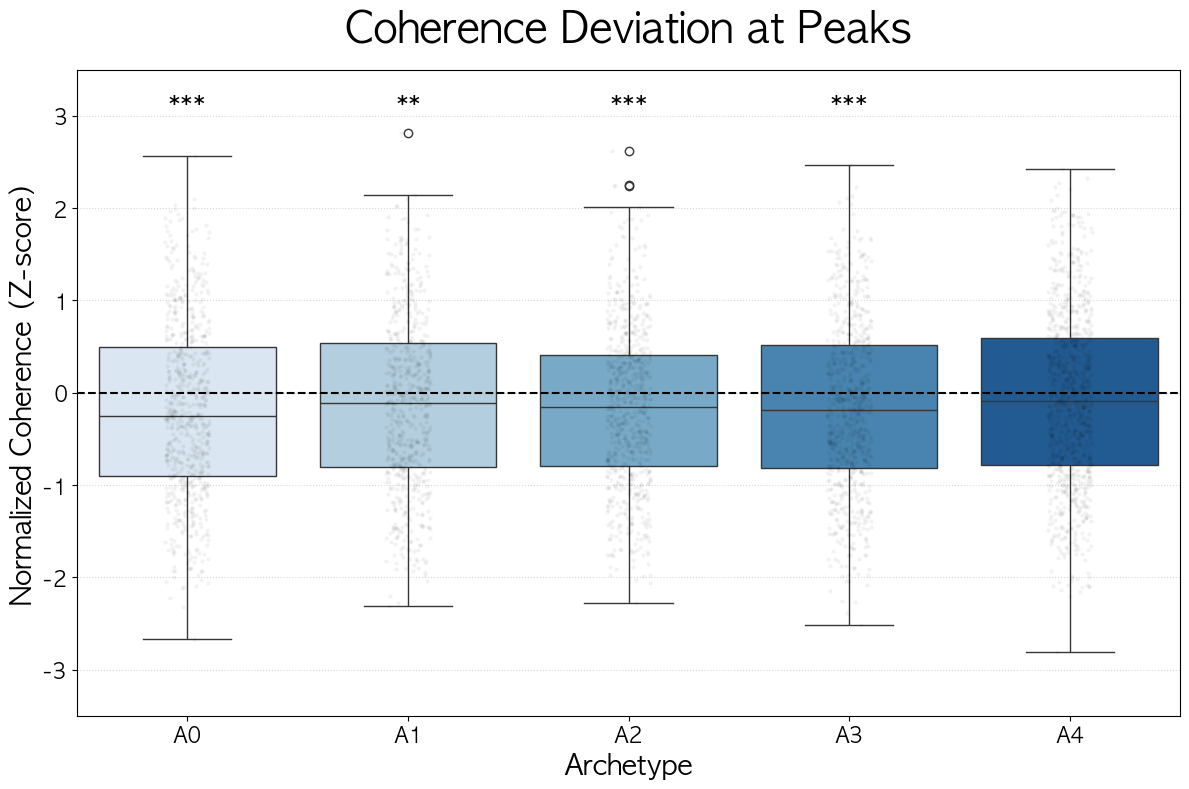

/var/folders/17/8f0ydqmd0vb_k2j226w720g00000gn/T/ipykernel_31644/3681959482.py:183: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_peaks, x="Cluster", y=metric, palette=color, order=archetypes, showfliers=True)


[INFO] Plot saved to: ./figure outputs/pointwise_validation_semanticshift.png


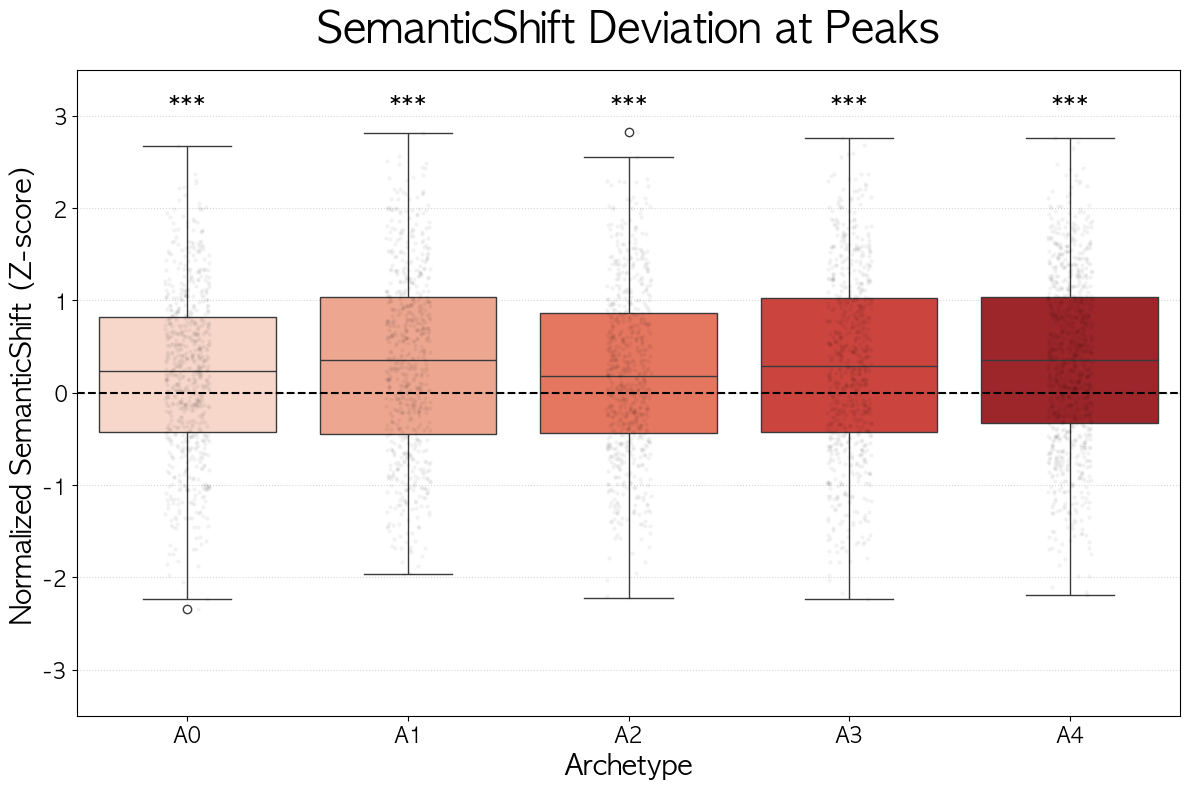

In [40]:
import os
import pandas as pd
import numpy as np
import ast
import platform
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, levene, ttest_1samp, wilcoxon, f_oneway, kruskal
from scipy.signal import find_peaks
import scikit_posthocs as sp
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ==========================================
# 0. Environment Setup
# ==========================================
def set_korean_font():
    """Configures fonts for plotting based on the operating system."""
    system = platform.system()
    if system == "Darwin": plt.rc('font', family='AppleGothic')
    elif system == "Windows": plt.rc('font', family='Malgun Gothic')
    plt.rcParams['axes.unicode_minus'] = False

set_korean_font()

BASE_PATH = "." 
FEAT_FILE = f"{BASE_PATH}/statistical_outputs/flash_fiction_with_all_features_50.csv"
CLUST_FILE = f"{BASE_PATH}/statistical_outputs/flash_fiction_clustered_surprisal_stable.csv"
OUTPUT_DIR = f"{BASE_PATH}/figure outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
RESULT_OUT = os.path.join(BASE_PATH, "statistical_outputs/peak_point_validation_report.csv")

# ==========================================
# 1. Utility Functions
# ==========================================
def safe_vec(x):
    """Safely parses string-encoded list representations."""
    if isinstance(x, list): return x
    try: return ast.literal_eval(x)
    except: return []

def get_z_score_stable(vec):
    """Normalization based on stable region (Bins 2-49) to avoid burn-in noise."""
    arr = np.array(vec)
    stable_region = arr[2:] 
    mu, sigma = np.mean(stable_region), np.std(stable_region)
    return (arr - mu) / sigma if sigma != 0 else np.zeros_like(arr)

def get_star(p):
    """Significance markers based on p-values."""
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    return "n.s."


import scikit_posthocs as sp
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ============================================================================
# 2. Main Analysis Pipeline (Omnibus + Post-hoc + Baseline Validation)
# ============================================================================

def main():
    print(f"\n[INFO] Initializing Comprehensive Point-wise Validation at Surprisal Peaks...")
    
    df_feat = pd.read_csv(FEAT_FILE)
    df_clust = pd.read_csv(CLUST_FILE)
    df_feat["cluster"] = df_clust["cluster_surp"].values

    peak_data_records = [] 
    summary_stats = []     

    # 1. Data parsing and peak collection (identical)
    for _, row in df_feat.iterrows():
        s_vec = safe_vec(row["surprisal_curve_50_smooth"])
        c_vec = safe_vec(row["coherence_curve_50_smooth"])
        m_vec = safe_vec(row["semantic_shift_curve_50_smooth"])
        if len(s_vec) < 50: continue
        
        s_z = get_z_score_stable(s_vec)
        c_z = get_z_score_stable(c_vec)
        m_z = get_z_score_stable(m_vec)
        
        peaks, _ = find_peaks(s_z[2:], height=1.0)
        actual_peaks = peaks + 2
        for p_idx in actual_peaks:
            peak_data_records.append({
                "Cluster": f"Archetype {int(row['cluster'])}",
                "Coherence": c_z[p_idx],
                "SemanticShift": m_z[p_idx]
            })

    df_peaks = pd.DataFrame(peak_data_records)
    archetypes = sorted(df_peaks["Cluster"].unique())
    num_metrics = 2
    bonferroni_factor = len(archetypes) * num_metrics

    # --- 2. Statistical analysis and output per metric ---
    for metric in ["Coherence", "SemanticShift"]:
        print("\n" + "="*110)
        print(f" [ANALYSIS] METRIC: {metric} ")
        print("="*110)

        # A. Normality Testing (Shapiro-Wilk per Group)
        print(f"\n[STEP 1] Normality Testing (Shapiro-Wilk)")
        print("-" * 50)
        groups = []
        all_normal = True
        for a in archetypes:
            vals = df_peaks[df_peaks["Cluster"] == a][metric].values
            groups.append(vals)
            stat_sw, p_sw = shapiro(vals)
            is_normal = p_sw > 0.05
            if not is_normal: all_normal = False
            print(f"{a:<15} | W: {stat_sw:.4f} | p: {p_sw:.4e} | {'Normal' if is_normal else 'Skewed'}")

        # B. Variance Homogeneity (Levene's Test)
        print(f"\n[STEP 2] Variance Homogeneity (Levene's Test)")
        stat_lev, p_lev = levene(*groups)
        is_equal_var = p_lev > 0.05
        print(f"Statistic: {stat_lev:.4f} | p-value: {p_lev:.4e} | {'Equal Variance' if is_equal_var else 'Unequal Variance'}")

        # C. Omnibus Comparison Selection (ANOVA vs Kruskal-Wallis)
        print(f"\n[STEP 3] Omnibus Comparison")
        if all_normal and is_equal_var:
            f_stat, p_omnibus = f_oneway(*groups)
            test_name, posthoc_type = "ANOVA", "Tukey HSD"
            stat_val = f_stat
        else:
            h_stat, p_omnibus = kruskal(*groups)
            test_name, posthoc_type = "Kruskal-Wallis", "Dunn"
            stat_val = h_stat
        print(f"Test Selected: {test_name} | Statistic: {stat_val:.4f} | p-value: {p_omnibus:.4e}")

        # D. Post-hoc Analysis
        if p_omnibus < 0.05:
            print(f"\n[STEP 4] Post-hoc Analysis ({posthoc_type})")
            if posthoc_type == "Tukey HSD":
                print(pairwise_tukeyhsd(df_peaks[metric], df_peaks["Cluster"]))
            else:
                ph_res = sp.posthoc_dunn(df_peaks, val_col=metric, group_col='Cluster', p_adjust='bonferroni')
                print(ph_res)
                ph_res.to_csv(f"{BASE_PATH}/statistical_outputs/posthoc_{metric.lower()}_dunn.csv")

        # E. Individual Baseline Validation (Against Z=0) - Table 6 Data
        print(f"\n[STEP 5] Individual Baseline Validation (Against Z=0)")
        print("-" * 105)
        print(f"{'Archetype':<15} | {'N':<6} | {'Mean(Z)':<10} | {'Method':<12} | {'Adj. P-value':<12} | {'Sig'}")
        print("-" * 105)

        for vals, a in zip(groups, archetypes):
            _, p_sw = shapiro(vals)
            if p_sw > 0.05:
                method = "One-sample T"
                _, p_raw = ttest_1samp(vals, 0)
            else:
                method = "Wilcoxon"
                _, p_raw = wilcoxon(vals) # vs zero
            
            p_adj = min(p_raw * bonferroni_factor, 1.0)
            mean_z = np.mean(vals)
            star = get_star(p_adj)
            
            summary_stats.append({
                "Metric": metric, "Archetype": a, "N": len(vals),
                "Mean_Z": round(mean_z, 4), "Method": method, 
                "P_Adj": p_adj, "Sig": star
            })
            print(f"{a:<15} | {len(vals):<6} | {mean_z:>10.4f} | {method:<12} | {p_adj:>12.2e} | {star}")

    # Save results
    pd.DataFrame(summary_stats).to_csv(RESULT_OUT, index=False)
    print(f"\n[FINISH] All diagnostics and Table 6 extraction complete.")

    # ==========================================
    # 3. Visualization: Detailed Deviation Plots
    # ==========================================
    for metric, color in [("Coherence", "Blues"), ("SemanticShift", "Reds")]:
        plt.figure(figsize=(12, 8))
        
        # Distribution Plot (Boxplot + Stripplot)
        # Note: showfliers=False prevents outliers from stretching the adjusted axis
        sns.boxplot(data=df_peaks, x="Cluster", y=metric, palette=color, order=archetypes, showfliers=True)
        sns.stripplot(data=df_peaks, x="Cluster", y=metric, color="black", alpha=0.05, size=3, order=archetypes)
        
        # Baseline reference line
        plt.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Baseline (Z=0)')
        
        # ---------------------------------------------------------
        # Axis Configuration as requested:
        # Range: -3.5 to 3.5 | Ticks: -3 to 3 (step=1)
        # ---------------------------------------------------------
        plt.ylim(-3.5, 3.5)
        plt.yticks(np.arange(-3, 4, 1),fontsize=15) # Displays -3, -2, -1, 0, 1, 2, 3
        
        # Add Significance Stars based on summary statistics
        for i, a in enumerate(archetypes):
            res = next(item for item in summary_stats if item["Archetype"] == a and item["Metric"] == metric)
            if res["Sig"] != "n.s.":
                # Position stars at Y=3.0 for consistent visibility within the range
                plt.text(i, 3.0, res["Sig"], ha='center', fontsize=20, fontweight='bold')

        # Labeling and Grid
        plt.title(f"{metric} Deviation at Peaks", fontsize=30, pad=20)
        plt.ylabel(f"Normalized {metric} (Z-score)", fontsize=20)
        plt.xlabel("Archetype", fontsize=20)
        short_labels = [a.replace("Archetype ", "A") for a in archetypes]

        plt.xticks(ticks=np.arange(len(archetypes)), labels=short_labels, fontsize=15)
        plt.grid(True, axis='y', linestyle=':', alpha=0.5)
        
        plt.tight_layout()
        
        # Saving the figure
        save_path = f"{OUTPUT_DIR}/pointwise_validation_{metric.lower()}.png"
        plt.savefig(save_path, dpi=300)
        print(f"[INFO] Plot saved to: {save_path}")
        plt.show()

if __name__ == "__main__":
    main()

## 7. Event-locked Dynamic Recovery Analysis: Narrative Resilience

This section quantifies the **structural elasticity** of each narrative archetype by analyzing how discourse signals (Coherence and Semantic Shift) recover following a surprisal shock ($Z > 1.0$). We operationalize narrative resilience through two primary metrics:

1.  **Time-to-Recovery (TTR):** The number of bins required for a signal to return to the story-specific baseline ($Z=0$).
2.  **Dynamic Recovery Slope ($S_{rec}$):** The average rate of change from the peak/trough back to the baseline, representing the intensity of the corrective narrative adjustment.

### Statistical Framework:

* **Event-segmentation:** Each significant peak is treated as a discrete event boundary, focusing on the post-peak window to observe recovery.
* **Assumption-Based Comparison:** We use **One-way ANOVA** to test for global differences between archetypes if normality (**Shapiro-Wilk**) and variance homogeneity (**Levene’s**) are met. Otherwise, the non-parametric **Kruskal-Wallis test** is utilized.
* **Post-hoc Analysis:** Depending on the omnibus test result, we perform **Tukey HSD** or **Dunn’s test (Bonferroni)** to identify specific pairs of archetypes that exhibit significantly different recovery mechanics (e.g., rapid resilience vs. lingering reorientation).

$$\mathrm{TTR} = t_{\mathrm{rec}} - t_0$$
$$S_{\mathrm{rec}} = \frac{V(t_{\mathrm{rec}}) - V(t_0)}{t_{\mathrm{rec}} - t_0}$$

[INFO] Initializing Event-locked Integrated Dynamic Analysis...

[ANALYSIS] Metric: Coherence Recovery Time (TTR)

[STEP 0] Descriptive Statistics
               mean     std  median  count
Cluster                                   
Archetype 0  4.2167  2.4297     4.0    263
Archetype 1  4.4432  2.5026     4.0    264
Archetype 2  4.3404  2.4074     4.0    285
Archetype 3  3.7790  2.3072     3.0    267
Archetype 4  4.1610  2.3623     4.0    354

[STEP 1] Normality Testing
Archetype 0 | W: 0.9232 | p: 2.1022e-10 | Skewed
Archetype 1 | W: 0.9282 | p: 5.3132e-10 | Skewed
Archetype 2 | W: 0.9344 | p: 6.4800e-10 | Skewed
Archetype 3 | W: 0.9085 | p: 1.0915e-11 | Skewed
Archetype 4 | W: 0.9265 | p: 3.5413e-12 | Skewed
[STEP 3] Kruskal-Wallis: Stat=12.0625, p=1.6893e-02

[STEP 4] Post-hoc Analysis

[ANALYSIS] Metric: Coherence Recovery Slope

[STEP 0] Descriptive Statistics
               mean     std  median  count
Cluster                                   
Archetype 0  0.2925  0.1774  0.2587

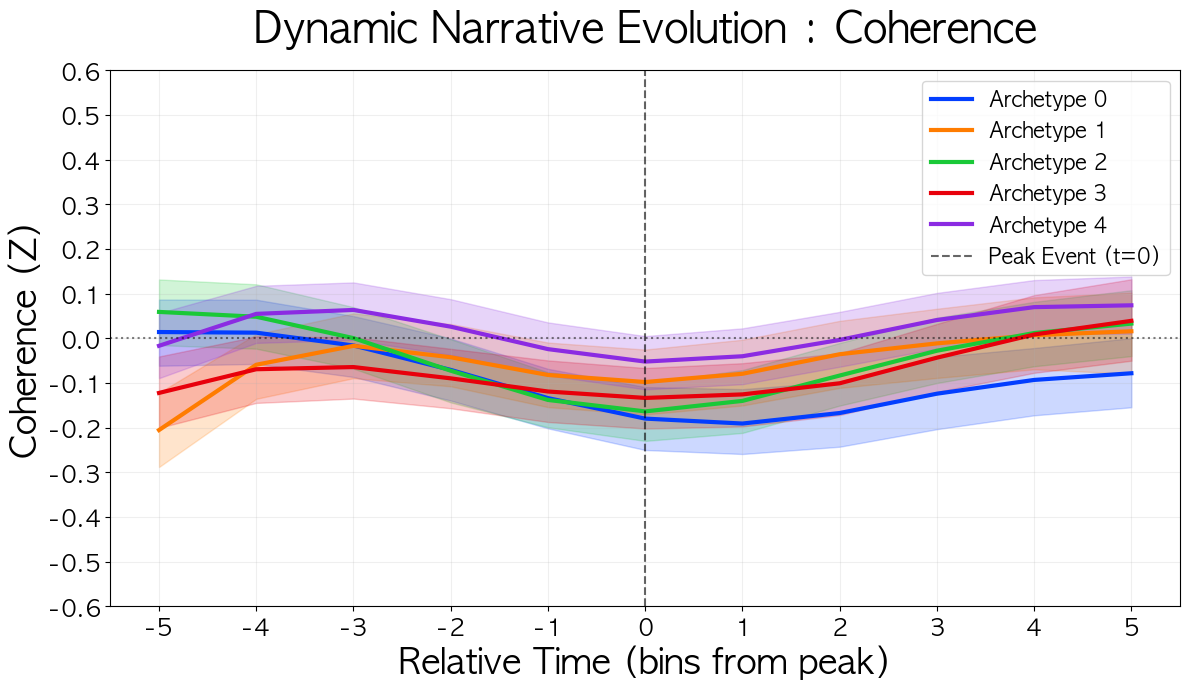

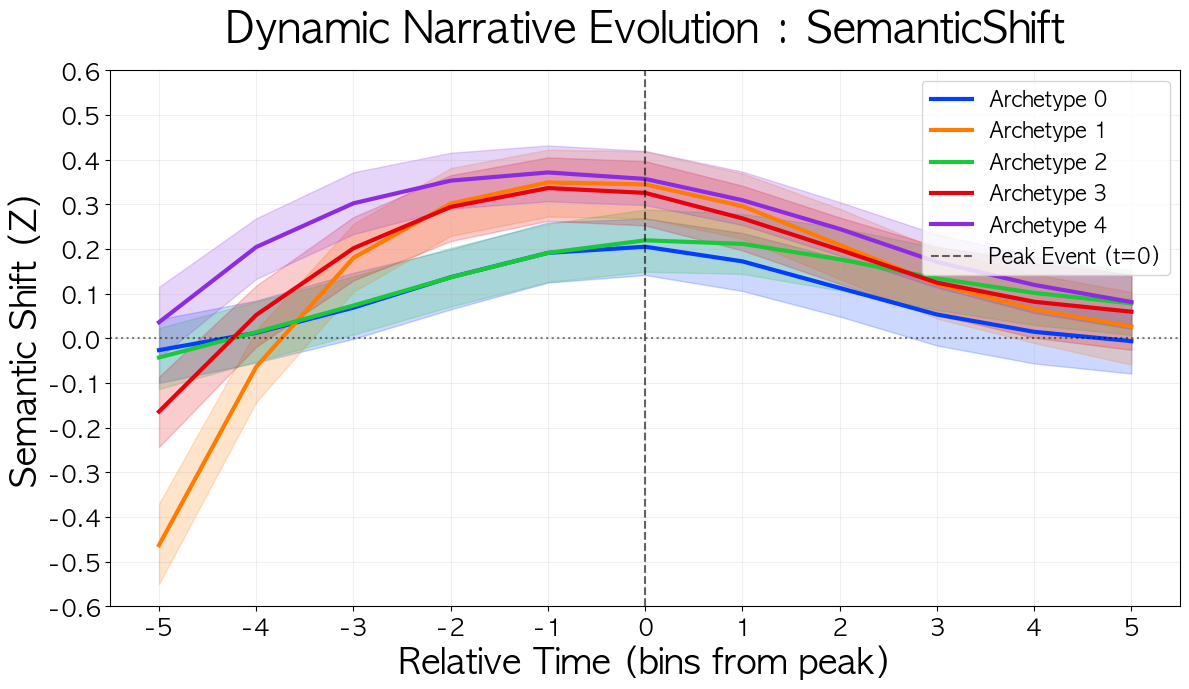


[SUCCESS] Statistical report saved to: ./statistical_outputs/recovery_statistical_report.txt


In [38]:
import os
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway
from scipy.signal import find_peaks
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import platform
from scipy.stats import shapiro, levene, kruskal
import scikit_posthocs as sp 


# ==========================================
# 0. Environment Setup
# ==========================================
def set_korean_font():
    system = platform.system()
    if system == "Darwin": plt.rc('font', family='AppleGothic')
    elif system == "Windows": plt.rc('font', family='Malgun Gothic')
    plt.rcParams['axes.unicode_minus'] = False

set_korean_font()

BASE_PATH = "." 
FEAT_FILE = f"{BASE_PATH}/statistical_outputs/flash_fiction_with_all_features_50.csv"
CLUST_FILE = f"{BASE_PATH}/statistical_outputs/flash_fiction_clustered_surprisal_stable.csv"
SAVE_DIR = os.path.join(BASE_PATH, "figure outputs")
os.makedirs(SAVE_DIR, exist_ok=True)

PEAK_THRESHOLD = 1.0
STATS_OUT = os.path.join(BASE_PATH, "statistical_outputs/recovery_statistical_report.txt")
SEARCH_WINDOW = 10 
TITLE_SIZE, LABEL_SIZE, TICK_SIZE = 30, 25, 17

# ==========================================
# 1. Utility Functions
# ==========================================
def safe_vec(x):
    try: return list(ast.literal_eval(x))
    except: return []

def get_z_norm_stable(vec):
    """Normalize using stable region (Bins 2-49)."""
    arr = np.array(vec)[2:] 
    if len(arr) < 2 or np.std(arr) == 0: return np.zeros_like(arr)
    return (arr - np.mean(arr)) / np.std(arr)

def calculate_dynamic_recovery(post_peak_series, metric_type="coherence"):
    """TTR: Steps to reach Z=0; Slope: Recovery rate."""
    ttr, slope = np.nan, np.nan
    if len(post_peak_series) <= 1: return ttr, slope
    peak_val = post_peak_series[0]
    for i in range(1, len(post_peak_series)):
        current_val = post_peak_series[i]
        if np.isnan(current_val): break
        recovered = (peak_val < 0 and current_val >= 0) if metric_type == "coherence" else (peak_val > 0 and current_val <= 0)
        if recovered:
            ttr = i
            slope = (current_val - peak_val) / i
            break
    return ttr, slope

# ==========================================
# 2. Main Analysis Pipeline
# ==========================================
def main():
    print(f"[INFO] Initializing Event-locked Integrated Dynamic Analysis...")
    df_feat = pd.read_csv(FEAT_FILE)
    df_clust = pd.read_csv(CLUST_FILE)
    df_feat["cluster"] = df_clust["cluster_surp"].values

    analysis_results = []
    plot_data = []

    for _, row in df_feat.iterrows():
        s_vec = safe_vec(row["surprisal_curve_50_smooth"])
        c_vec = safe_vec(row["coherence_curve_50_smooth"])
        m_vec = safe_vec(row["semantic_shift_curve_50_smooth"])
        if len(s_vec) < 10: continue
        
        s_z = get_z_norm_stable(s_vec)
        c_z = get_z_norm_stable(c_vec)
        m_z = get_z_norm_stable(m_vec)
        peaks, _ = find_peaks(s_z, height=PEAK_THRESHOLD)
        
        for p_idx in peaks:
            post_c, post_m = c_z[p_idx : p_idx + SEARCH_WINDOW], m_z[p_idx : p_idx + SEARCH_WINDOW]
            ttr_c, slope_c = calculate_dynamic_recovery(post_c, "coherence")
            ttr_m, slope_m = calculate_dynamic_recovery(post_m, "semantic_shift")
            
            analysis_results.append({
                "Cluster": f"Archetype {row['cluster']}",
                "TTR_C": ttr_c, "Slope_C": slope_c, "TTR_M": ttr_m, "Slope_M": slope_m
            })
            
            start, end = max(0, p_idx - 5), min(len(c_z), p_idx + 6)
            for t_rel, idx in enumerate(range(start, end), -5):
                if 0 <= idx < len(c_z):
                    plot_data.append({"Cluster": f"Archetype {row['cluster']}", "Time": t_rel, "Coherence": c_z[idx], "SemanticShift": m_z[idx]})

    df_res, df_plot = pd.DataFrame(analysis_results), pd.DataFrame(plot_data)

    
    # ==========================================
    # 3. STATISTICAL REPORTING (Updated logic)
    # ==========================================
    with open(STATS_OUT, "w", encoding="utf-8") as f:
        f.write("=== MULTI-PEAK DYNAMIC RECOVERY STATISTICAL REPORT ===\n\n")
        target_metrics = [("TTR_C", "Coherence Recovery Time (TTR)"), 
                          ("Slope_C", "Coherence Recovery Slope"),
                          ("TTR_M", "Semantic Shift Recovery Time (TTR)"), 
                          ("Slope_M", "Semantic Shift Recovery Slope")]
        
        alpha = 0.05
        
        for col, name in target_metrics:
            sub_df = df_res.dropna(subset=[col])
            
            # Skip if no valid data exists for this metric
            if sub_df.empty:
                continue

            header = f"\n[ANALYSIS] Metric: {name}\n" + "="*70
            print(header); f.write(header + "\n")

            # ---------------------------------------------------------
            # [STEP 0] Descriptive Statistics per Archetype
            # ---------------------------------------------------------
            print(f"\n[STEP 0] Descriptive Statistics")
            f.write("\n[STEP 0] Descriptive Statistics (Summary)\n" + "-"*50 + "\n")
            
            # Detailed grouping for cleaner output
            desc_stats = sub_df.groupby("Cluster")[col].agg(['mean', 'std', 'median', 'count']).round(4)
            
            print(desc_stats)
            f.write(desc_stats.to_string() + "\n\n")
            f.write(f"* Total peaks recovered (window={SEARCH_WINDOW}): {desc_stats['count'].sum()}\n")
            f.flush()  # Force write to disk immediately

            # ---------------------------------------------------------
            # [STEP 1] Normality Testing (Shapiro-Wilk)
            # ---------------------------------------------------------
            print(f"\n[STEP 1] Normality Testing")
            f.write("\n[STEP 1] Normality Testing (Shapiro-Wilk)\n" + "-"*50 + "\n")
            
            groups = []
            all_normal = True
            for i in range(5):
                vals = sub_df[sub_df["Cluster"] == f"Archetype {i}"][col].values
                
                if len(vals) >= 3:
                    groups.append(vals)
                    stat_sw, p_sw = shapiro(vals)
                    is_normal = p_sw > alpha
                    if not is_normal: all_normal = False
                    
                    msg = f"Archetype {i:<1} | W: {stat_sw:.4f} | p: {p_sw:.4e} | {'Normal' if is_normal else 'Skewed'}"
                    print(msg); f.write(msg + "\n")
                else:
                    msg = f"Archetype {i:<1} | Insufficient data (N={len(vals)})"
                    print(msg); f.write(msg + "\n")
            f.flush()

            # ---------------------------------------------------------
            # [STEP 2-4] Group Comparison and Post-hoc
            # ---------------------------------------------------------
            if len(groups) >= 2:
                # STEP 2: Levene
                stat_lev, p_lev = levene(*groups)
                is_equal_var = p_lev > alpha
                f.write(f"\n[STEP 2] Variance Homogeneity (Levene): p={p_lev:.4e}\n")

                # STEP 3: Omnibus
                if all_normal and is_equal_var:
                    test_name = "ANOVA"
                    stat_om, p_om = f_oneway(*groups)
                else:
                    test_name = "Kruskal-Wallis"
                    stat_om, p_om = kruskal(*groups)
                
                res_msg = f"[STEP 3] {test_name}: Stat={stat_om:.4f}, p={p_om:.4e}"
                print(res_msg); f.write(res_msg + "\n")

                # STEP 4: Post-hoc (Only if significant)
                if p_om < alpha:
                    print(f"\n[STEP 4] Post-hoc Analysis")
                    f.write("\n[STEP 4] Post-hoc Analysis\n")
                    if test_name == "ANOVA":
                        tukey = pairwise_tukeyhsd(sub_df[col], sub_df['Cluster'], alpha=alpha)
                        f.write(str(tukey) + "\n")
                    else:
                        dunn = sp.posthoc_dunn(sub_df, val_col=col, group_col='Cluster', p_adjust='bonferroni')
                        f.write(str(dunn) + "\n")
            else:
                f.write("\n[ERROR] Insufficient groups for comparison.\n")
            f.flush()


    # ==========================================
    # 4. Visualization: Recovery Trajectories
    # ==========================================
    PLOT_LIMIT = 0.6
    
    archetype_order = [f"Archetype {i}" for i in range(5)]
    
    for metric, ylabel in [("Coherence", "Coherence (Z)"), ("SemanticShift", "Semantic Shift (Z)")]:
        plt.figure(figsize=(12, 7))
        
        sns.lineplot(
            data=df_plot, 
            x="Time", 
            y=metric, 
            hue="Cluster", 
            hue_order=archetype_order, 
            palette="bright", 
            linewidth=3, 
            errorbar=('ci', 95)
        )
        
        plt.axvline(0, color='black', linestyle='--', alpha=0.6, label='Peak Event (t=0)')
        plt.axhline(0, color='black', linestyle=':', alpha=0.5)
        
        plt.ylim(-PLOT_LIMIT, PLOT_LIMIT)
        plt.xticks(np.arange(-5, 6), fontsize=TICK_SIZE)
        plt.yticks(np.arange(-0.6, 0.7, 0.1), fontsize=TICK_SIZE)
        
        plt.title(f"Dynamic Narrative Evolution : {metric}", fontsize=TITLE_SIZE, pad=20)
        plt.xlabel("Relative Time (bins from peak)", fontsize=LABEL_SIZE)
        plt.ylabel(ylabel, fontsize=LABEL_SIZE)
        
        plt.legend(loc='upper right', frameon=True, fontsize=15)
        
        plt.grid(True, alpha=0.2)
        plt.tight_layout()
        plt.savefig(os.path.join(SAVE_DIR, f"recovery_dynamics_{metric.lower()}.png"), dpi=300)
        plt.show()

    print(f"\n[SUCCESS] Statistical report saved to: {STATS_OUT}")

if __name__ == "__main__":
    main()